# Model Training - Robust CNN-BiLSTM-Attention

This notebook follows a practical methodology inspired by your earlier baseline notebooks, adapted to this project pipeline:

1. Load window arrays (or rebuild safely if invalid)
2. Normalize features using training-only statistics
3. Train CNN + BiLSTM + temporal attention with binary cross-entropy
4. Tune decision threshold on validation PR curve (recall-focused)
5. Evaluate on test set with PR/ROC/F1 and confusion matrix

Goal: stable generalization and reduced overfitting under class imbalance.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Dropout,
    Bidirectional, LSTM, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

DATA_DIR = "../data"
MODEL_DIR = "../models"
FIG_DIR = "../paper/images"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 20
STEP_SIZE = 5
FORCE_REBUILD_WINDOWS = True
FEATURES = [
    "Pressure (bar)", "Flow Rate (L/s)", "Temperature (°C)",
    "pressure_delta", "flow_zscore", "pf_ratio"
]

print(f"TensorFlow {tf.__version__}")

I0000 00:00:1774138048.032386   30659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774138048.032821   30659 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774138048.078144   30659 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0


I0000 00:00:1774138049.128284   30659 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774138049.128572   30659 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Data and Configuration
This section imports dependencies, sets random seeds for reproducibility, and defines core paths and hyperparameters such as window size and feature columns.

Key idea: keep training deterministic and make all pipeline settings explicit before loading data.

In [2]:
def create_windows_for_group(group_df, features, window_size=20, step_size=5):
    vals = group_df[features].values
    labels = group_df['Leak Status'].values

    X_list, y_list = [], []
    for start in range(0, len(group_df) - window_size + 1, step_size):
        end = start + window_size
        X_list.append(vals[start:end])
        # Window label = 1 if ANY timestep in the window is leak
        y_list.append(int(labels[start:end].max() > 0))
    return X_list, y_list


def ensure_engineered_columns(df):
    needed = {'pressure_delta', 'flow_zscore', 'pf_ratio'}
    if needed.issubset(df.columns):
        return df

    df = df.sort_values(['Sensor_ID', 'Timestamp']).reset_index(drop=True).copy()

    if 'pressure_delta' not in df.columns:
        df['pressure_delta'] = df.groupby('Sensor_ID')['Pressure (bar)'].diff().fillna(0)

    if 'pf_ratio' not in df.columns:
        df['pf_ratio'] = df['Pressure (bar)'] / (df['Flow Rate (L/s)'] + 1e-8)

    if 'flow_zscore' not in df.columns:
        sensor_mu = df.groupby('Sensor_ID')['Flow Rate (L/s)'].transform('mean')
        sensor_sd = df.groupby('Sensor_ID')['Flow Rate (L/s)'].transform('std').fillna(0)
        df['flow_zscore'] = (df['Flow Rate (L/s)'] - sensor_mu) / (sensor_sd + 1e-8)

    return df


def rebuild_arrays_from_engineered_csv(data_path, features, window_size=20, step_size=5):
    df = pd.read_csv(data_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = ensure_engineered_columns(df)
    df = df.sort_values(['Sensor_ID', 'Timestamp']).reset_index(drop=True)

    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required feature columns for windowing: {missing}')

    X_train_l, y_train_l = [], []
    X_test_l, y_test_l = [], []

    # Temporal split per sensor: 80% train, 20% test
    for sensor_id, group in df.groupby('Sensor_ID'):
        group = group.sort_values('Timestamp').reset_index(drop=True)
        X_s, y_s = create_windows_for_group(group, features, window_size, step_size)
        n = len(X_s)
        if n < 2:
            continue

        t_end = int(n * 0.80)
        X_train_l.extend(X_s[:t_end])
        y_train_l.extend(y_s[:t_end])
        X_test_l.extend(X_s[t_end:])
        y_test_l.extend(y_s[t_end:])

    X_train = np.array(X_train_l)
    y_train = np.array(y_train_l)
    X_test = np.array(X_test_l)
    y_test = np.array(y_test_l)

    # NOTE: No oversampling here to keep calibration/test distributions realistic.
    return X_train, y_train, X_test, y_test


def load_or_rebuild_arrays():
    def _safe_load(name):
        path = f'{DATA_DIR}/{name}.npy'
        if os.path.exists(path):
            return np.load(path)
        return np.array([])

    X_train = _safe_load('X_train')
    y_train = _safe_load('y_train')
    X_test = _safe_load('X_test')
    y_test = _safe_load('y_test')

    valid = (
        isinstance(X_train, np.ndarray) and X_train.ndim == 3 and X_train.shape[0] > 0 and
        isinstance(X_test, np.ndarray) and X_test.ndim == 3 and X_test.shape[0] > 0 and
        (not FORCE_REBUILD_WINDOWS)
    )

    if not valid:
        print('Rebuilding arrays from data_engineered.csv (train/test only)...')
        engineered_path = f'{DATA_DIR}/data_engineered.csv'
        X_train, y_train, X_test, y_test = rebuild_arrays_from_engineered_csv(
            engineered_path, FEATURES, window_size=WINDOW_SIZE, step_size=STEP_SIZE
        )

        np.save(f'{DATA_DIR}/X_train.npy', X_train)
        np.save(f'{DATA_DIR}/y_train.npy', y_train)
        np.save(f'{DATA_DIR}/X_test.npy', X_test)
        np.save(f'{DATA_DIR}/y_test.npy', y_test)
        print('Rebuilt arrays saved to data/*.npy')

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_or_rebuild_arrays()

print('=== DATASET SUMMARY (Train/Test only) ===')
print(f'X_train: {X_train.shape} | leak={y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'X_test : {X_test.shape} | leak={y_test.sum()} ({y_test.mean()*100:.2f}%)')

Rebuilding arrays from data_engineered.csv (train/test only)...
Rebuilt arrays saved to data/*.npy
=== DATASET SUMMARY (Train/Test only) ===
X_train: (863, 20, 6) | leak=329 (38.12%)
X_test : (221, 20, 6) | leak=91 (41.18%)


## Train/Calibration Split Strategy
The external split is train/test only. Then we create an internal calibration split from the training set.

Why this matters:
- The test set remains untouched for final evaluation.
- Calibration data is used for early stopping and threshold tuning without leaking test information.

In [3]:
# Internal calibration split from TRAIN only (for early stopping + threshold tuning)
# External data split remains strictly Train/Test.

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print('=== TRAIN / CALIBRATION (from train only) ===')
print(f'X_fit: {X_fit.shape} | leak={y_fit.sum()} ({y_fit.mean()*100:.2f}%)')
print(f'X_cal: {X_cal.shape} | leak={y_cal.sum()} ({y_cal.mean()*100:.2f}%)')

=== TRAIN / CALIBRATION (from train only) ===
X_fit: (690, 20, 6) | leak=263 (38.12%)
X_cal: (173, 20, 6) | leak=66 (38.15%)


In [4]:
# Mild balancing on fit-set only (avoid distorting calibration/test)
TARGET_TRAIN_LEAK_RATIO = 0.20
current_ratio = float(y_fit.mean())

if current_ratio < TARGET_TRAIN_LEAK_RATIO:
    print(f'Fit leak ratio {current_ratio:.3f} is low; upsampling leaks to {TARGET_TRAIN_LEAK_RATIO:.2f}.')
    pos_idx = np.where(y_fit == 1)[0]
    neg_idx = np.where(y_fit == 0)[0]

    leaks_needed = int((TARGET_TRAIN_LEAK_RATIO * len(neg_idx)) / (1.0 - TARGET_TRAIN_LEAK_RATIO))
    add_count = max(0, leaks_needed - len(pos_idx))

    if add_count > 0 and len(pos_idx) > 0:
        add_pos = np.random.default_rng(42).choice(pos_idx, size=add_count, replace=True)
        X_fit = np.concatenate([X_fit, X_fit[add_pos]], axis=0)
        y_fit = np.concatenate([y_fit, y_fit[add_pos]], axis=0)

if current_ratio > 0.35:
    print(f'Fit leak ratio {current_ratio:.3f} is high; capping to 0.35.')
    pos_idx = np.where(y_fit == 1)[0]
    neg_idx = np.where(y_fit == 0)[0]
    leaks_keep = int((0.35 * len(neg_idx)) / (1.0 - 0.35))
    leaks_keep = max(1, min(leaks_keep, len(pos_idx)))
    keep_pos = np.random.default_rng(42).choice(pos_idx, size=leaks_keep, replace=False)
    keep_idx = np.concatenate([neg_idx, keep_pos])
    np.random.default_rng(42).shuffle(keep_idx)
    X_fit = X_fit[keep_idx]
    y_fit = y_fit[keep_idx]

print(f'Final fit leak ratio: {y_fit.mean()*100:.2f}%')
print(f'Fit shape after ratio control: {X_fit.shape}')

Fit leak ratio 0.381 is high; capping to 0.35.
Final fit leak ratio: 34.91%
Fit shape after ratio control: (656, 20, 6)


In [5]:
# Standardize features using FIT statistics only (prevents leakage)
scaler = StandardScaler()

n_fit, win_size, n_feat = X_fit.shape
n_cal = X_cal.shape[0]
n_test = X_test.shape[0]

X_fit_2d = X_fit.reshape(-1, n_feat)
X_cal_2d = X_cal.reshape(-1, n_feat)
X_test_2d = X_test.reshape(-1, n_feat)

X_fit_2d = scaler.fit_transform(X_fit_2d)
X_cal_2d = scaler.transform(X_cal_2d)
X_test_2d = scaler.transform(X_test_2d)

X_fit = X_fit_2d.reshape(n_fit, win_size, n_feat).astype(np.float32)
X_cal = X_cal_2d.reshape(n_cal, win_size, n_feat).astype(np.float32)
X_test = X_test_2d.reshape(n_test, win_size, n_feat).astype(np.float32)

y_fit = y_fit.astype(np.float32).reshape(-1)
y_cal = y_cal.astype(np.float32).reshape(-1)
y_test = y_test.astype(np.float32).reshape(-1)

print('Scaling complete.')
print(f'Fit mean (approx): {X_fit.mean(axis=(0,1)).round(3)}')
print(f'Fit std  (approx): {X_fit.std(axis=(0,1)).round(3)}')

Scaling complete.
Fit mean (approx): [-0. -0.  0. -0. -0.  0.]
Fit std  (approx): [1. 1. 1. 1. 1. 1.]


## Model Architecture and Loss
This model combines a small CNN front-end, a BiLSTM sequence encoder, and temporal attention.

Training uses standard binary cross-entropy loss with sigmoid output for binary leak classification.

In [6]:
def build_cnn_bilstm_attention(window_size, n_features):
    inp = Input(shape=(window_size, n_features), name='input')

    # Slightly smaller model to reduce overfitting on small data
    x = Conv1D(32, kernel_size=3, padding='same', activation='relu', name='conv1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Conv1D(32, kernel_size=5, padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.30, name='drop_cnn')(x)

    x = Bidirectional(LSTM(32, return_sequences=True, dropout=0.25), name='bilstm')(x)

    attn_scores = Dense(1, activation='tanh', name='attn_score')(x)
    attn_weights = tf.keras.layers.Softmax(axis=1, name='attn_weight')(attn_scores)

    x = tf.keras.layers.Multiply(name='attn_mul')([x, attn_weights])
    x = tf.keras.layers.Lambda(lambda z: tf.reduce_sum(z, axis=1), name='attn_context')(x)

    x = Dense(16, activation='relu', name='dense1')(x)
    x = Dropout(0.40, name='drop_dense')(x)
    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc_roc', curve='ROC'),
            tf.keras.metrics.AUC(name='auc_pr', curve='PR'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_cnn_bilstm_attention(X_fit.shape[1], X_fit.shape[2])
model.summary()

E0000 00:00:1774138049.413504   30659 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 20, 32)    │        608 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 20, 32)    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 20, 32)    │      5,152 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 20, 32)    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn (Dropout)  │ (None, 20, 32)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 20, 64)    │     16,640 │ drop_cnn[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 20, 1)     │         65 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weight         │ (None, 20, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_mul (Multiply) │ (None, 20, 64)    │          0 │ bilstm[0][0],     │
│                     │                   │            │ attn_weight[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 64)        │          0 │ attn_mul[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 16)        │      1,040 │ attn_context[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 16)        │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ drop_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,778 (92.88 KB)

 Trainable params: 23,650 (92.38 KB)

 Non-trainable params: 128 (512.00 B)

In [7]:
callbacks = [
    EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{MODEL_DIR}/best_model.keras',
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_fit, y_fit,
    validation_data=(X_cal, y_cal),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

best_pr = float(np.max(history.history['val_auc_pr']))
best_roc = float(np.max(history.history['val_auc_roc']))
print(f'Best cal AUC-PR: {best_pr:.4f}')
print(f'Best cal AUC-ROC: {best_roc:.4f}')

Epoch 1/150
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc_pr: 0.4027 - auc_roc: 0.5925 - loss: 0.6857 - precision: 0.3987 - recall: 0.6366
Epoch 1: val_auc_pr improved from None to 0.81520, saving model to ../models/best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - auc_pr: 0.4934 - auc_roc: 0.6396 - loss: 0.6649 - precision: 0.4560 - recall: 0.4978 - val_auc_pr: 0.8152 - val_auc_roc: 0.8347 - val_loss: 0.6658 - val_precision: 0.8947 - val_recall: 0.5152 - learning_rate: 5.0000e-04
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.6347 - auc_roc: 0.7492 - loss: 0.6007 - precision: 0.6517 - recall: 0.3842
Epoch 2: val_auc_pr improved from 0.81520 to 0.85187, saving model to ../models/best_model.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc_pr: 0.6833 - auc_roc: 0.7717 - loss: 0.5862 - precision: 0.6899 - recall: 0.3886 - val_auc_pr: 0.8519 - val_auc_roc: 0.8750 - val_loss: 0.6256 - val_precision: 0.8302 - val_recall: 0.6667 - learning_rate: 5.0000e-04
Epoch 3/1

## Training Procedure
Model training uses early stopping and learning-rate reduction based on calibration AUC-PR.

Goal: stop before overfitting while still allowing enough epochs to learn leak patterns.

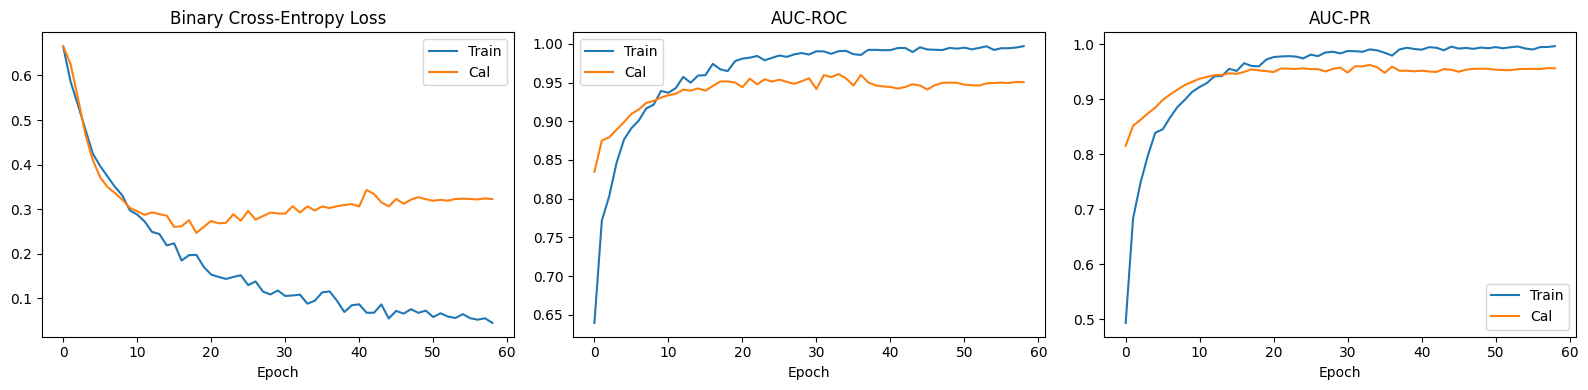

Best epoch = 34
Train AUC-PR @best: 0.9906
Cal   AUC-PR @best: 0.9624
Gap (train-cal): 0.0282


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Cal')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc_roc'], label='Train')
axes[1].plot(history.history['val_auc_roc'], label='Cal')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc_pr'], label='Train')
axes[2].plot(history.history['val_auc_pr'], label='Cal')
axes[2].set_title('AUC-PR')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# quick overfitting signal
best_ep = int(np.argmax(history.history['val_auc_pr']))
train_pr_best = history.history['auc_pr'][best_ep]
cal_pr_best = history.history['val_auc_pr'][best_ep]
print(f'Best epoch = {best_ep + 1}')
print(f'Train AUC-PR @best: {train_pr_best:.4f}')
print(f'Cal   AUC-PR @best: {cal_pr_best:.4f}')
print(f'Gap (train-cal): {(train_pr_best - cal_pr_best):.4f}')

In [9]:
# Calibration threshold tuning
y_cal_proba = model.predict(X_cal, verbose=0).flatten()

precision, recall, thresholds = precision_recall_curve(y_cal, y_cal_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
f1_for_thresh = f1_scores[:-1]

idx_f1 = int(np.nanargmax(f1_for_thresh))
th_f1 = float(thresholds[idx_f1])

TARGET_RECALL = 0.90
candidate_idx = np.where(recall[:-1] >= TARGET_RECALL)[0]
if len(candidate_idx) > 0:
    idx_rec = int(candidate_idx[np.argmax(precision[candidate_idx])])
    th_recall = float(thresholds[idx_rec])
else:
    th_recall = th_f1

# Accuracy-optimized threshold on calibration set
acc_scores = [np.mean((y_cal_proba >= t).astype(int) == y_cal) for t in thresholds]
idx_acc = int(np.argmax(acc_scores))
th_acc = float(thresholds[idx_acc])

# Conservative adjustment to reduce false positives under train/test class-shift
th_acc_conservative = min(0.95, th_acc + 0.03)

# Choose operating mode:
# - "balanced_f1": recommended for leak detection trade-off (default)
# - "max_accuracy": best calibration accuracy
# - "max_accuracy_conservative": fewer false alarms but may miss leaks
# - "high_recall": maximize leak capture
THRESHOLD_MODE = 'balanced_f1'
if THRESHOLD_MODE == 'balanced_f1':
    THRESHOLD = th_f1
elif THRESHOLD_MODE == 'high_recall':
    THRESHOLD = th_recall
elif THRESHOLD_MODE == 'max_accuracy':
    THRESHOLD = th_acc
else:
    THRESHOLD = th_acc_conservative

print('=== THRESHOLD TUNING (Calibration) ===')
print(f'Best F1 threshold          : {th_f1:.4f}')
print(f'High-recall threshold      : {th_recall:.4f}')
print(f'Max-accuracy threshold     : {th_acc:.4f}')
print(f'Conservative accuracy th   : {th_acc_conservative:.4f}')
print(f'Selected mode              : {THRESHOLD_MODE}')
print(f'Selected threshold         : {THRESHOLD:.4f}')
print(f'Best calibration F1        : {f1_for_thresh[idx_f1]:.4f}')
print(f'Best calibration acc       : {acc_scores[idx_acc]:.4f}')

np.save(f'{MODEL_DIR}/best_threshold.npy', np.array([THRESHOLD]))
print(f'Saved -> {MODEL_DIR}/best_threshold.npy')

=== THRESHOLD TUNING (Calibration) ===
Best F1 threshold          : 0.0200
High-recall threshold      : 0.0154
Max-accuracy threshold     : 0.0200
Conservative accuracy th   : 0.0500
Selected mode              : balanced_f1
Selected threshold         : 0.0200
Best calibration F1        : 0.9147
Best calibration acc       : 0.9364
Saved -> ../models/best_threshold.npy


## Threshold Selection
Predicted probabilities are converted to class labels using a threshold selected on the calibration split.

Multiple policies are computed (best F1, high recall, max accuracy), then one operating mode is chosen for deployment trade-offs.

In [10]:
# Test evaluation
y_test_proba = model.predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

test_roc = roc_auc_score(y_test, y_test_proba)
test_pr = average_precision_score(y_test, y_test_proba)

print("=== TEST RESULTS ===")
print(f"Threshold: {THRESHOLD:.4f}")
print(f"AUC-ROC : {test_roc:.4f}")
print(f"AUC-PR  : {test_pr:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Leak"], digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(cm)

=== TEST RESULTS ===
Threshold: 0.0200
AUC-ROC : 0.9456
AUC-PR  : 0.9552

              precision    recall  f1-score   support

      Normal     0.9185    0.9538    0.9358       130
        Leak     0.9302    0.8791    0.9040        91

    accuracy                         0.9231       221
   macro avg     0.9244    0.9165    0.9199       221
weighted avg     0.9233    0.9231    0.9227       221

Confusion matrix:
[[124   6]
 [ 11  80]]


## Final Test Evaluation
This section reports final test metrics and visual diagnostics (PR, ROC, confusion matrix).

Interpretation focus:
- AUC metrics for ranking quality.
- Confusion matrix for operational false alarms vs missed leaks.
- Threshold diagnostics for deployment sensitivity.

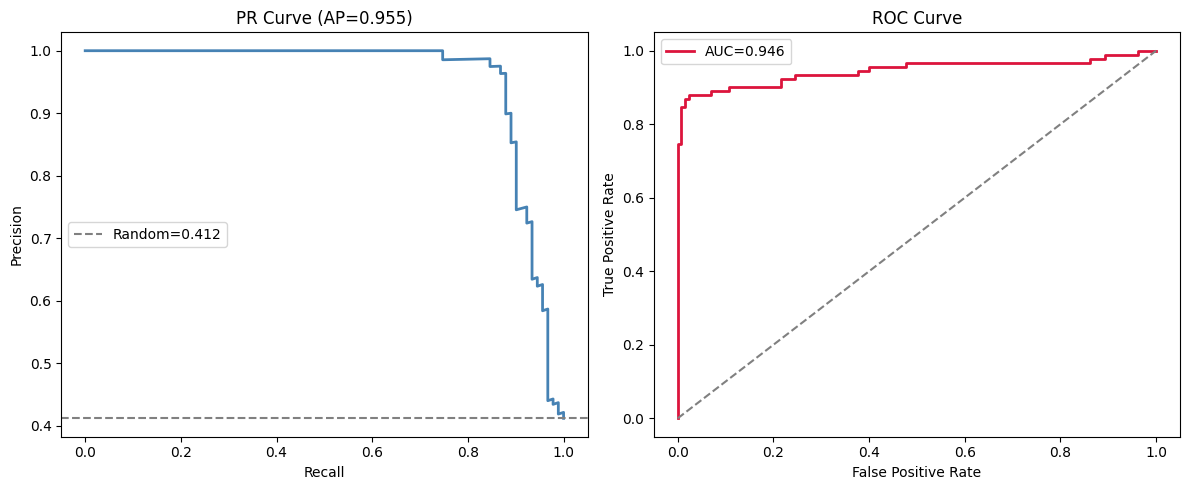

In [11]:
# PR and ROC curves (TEST)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR curve on test
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
axes[0].plot(recall_test, precision_test, color='steelblue', lw=2)
axes[0].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Random={y_test.mean():.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve (AP={test_pr:.3f})')
axes[0].legend()

# ROC curve on test
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC={test_roc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig7_pr_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

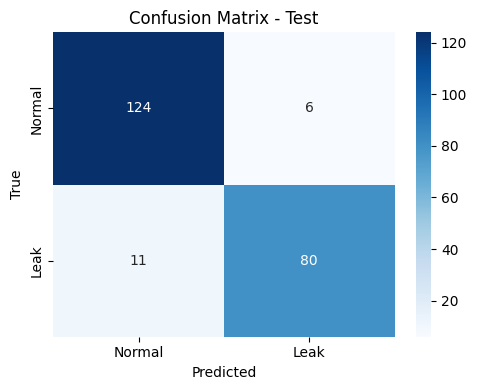

Saved model -> ../models/best_model.keras


In [12]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Leak"],
    yticklabels=["Normal", "Leak"], ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Test")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig8_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Save final model
model.save(f"{MODEL_DIR}/best_model.keras")
print(f"Saved model -> {MODEL_DIR}/best_model.keras")

In [13]:
# Threshold diagnostics on test
from sklearn.metrics import precision_score, recall_score, f1_score

candidates = {
    'selected_threshold': THRESHOLD,
    'best_f1_on_cal': float(th_f1) if 'th_f1' in globals() else THRESHOLD,
}

print('=== THRESHOLD DIAGNOSTICS (TEST) ===')
for name, th in candidates.items():
    pred = (y_test_proba >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f = f1_score(y_test, pred, zero_division=0)
    print(f'{name:20s} th={th:.4f} | precision={p:.4f} recall={r:.4f} f1={f:.4f}')

=== THRESHOLD DIAGNOSTICS (TEST) ===
selected_threshold   th=0.0200 | precision=0.9302 recall=0.8791 f1=0.9040
best_f1_on_cal       th=0.0200 | precision=0.9302 recall=0.8791 f1=0.9040


In [14]:
# Optional diagnostics: threshold sweep
ths = np.linspace(0.05, 0.95, 37)
acc_list, f1_list = [], []
for t in ths:
    pred = (y_test_proba >= t).astype(int)
    acc_list.append((pred == y_test).mean())
    f1_list.append((2 * (np.sum((pred==1)&(y_test==1))) / (2*np.sum((pred==1)&(y_test==1)) + np.sum((pred==1)&(y_test==0)) + np.sum((pred==0)&(y_test==1)) + 1e-8)))

best_acc_idx = int(np.argmax(acc_list))
best_f1_idx = int(np.argmax(f1_list))
print('=== TEST THRESHOLD SWEEP (DIAGNOSTIC) ===')
print(f'Best acc threshold (test-only diagnostic): {ths[best_acc_idx]:.3f} | acc={acc_list[best_acc_idx]:.4f}')
print(f'Best f1 threshold  (test-only diagnostic): {ths[best_f1_idx]:.3f} | f1={f1_list[best_f1_idx]:.4f}')

=== TEST THRESHOLD SWEEP (DIAGNOSTIC) ===
Best acc threshold (test-only diagnostic): 0.050 | acc=0.9231
Best f1 threshold  (test-only diagnostic): 0.050 | f1=0.8982
